# Switching Bayesian Observer — Python starter

Python/Jupyter port of the core model from **Laquitaine & Gardner (2018), *A Switching Observer for Human Perceptual Estimation*** (original code in MATLAB: `projInference`).

This notebook re-implements the **computational core** of the model so you can extend it to **MAP/switching**, **sampling**, and **online/sequential** observers. It is self-contained: every model function lives in a cell here (no MATLAB, no `SL*` helpers needed).

**What the model does (one paragraph).** On each trial the subject sees a noisy motion stimulus whose true direction is `d`. Their brain draws a noisy sensory *measurement* `m ~ vonMises(d, k_llh)` (larger `k_llh` = more reliable = higher coherence). They combine the *likelihood* of `m` with a *learnt prior* over directions (a von Mises centred on 225° whose width is set by the block) to form a *posterior*. A **readout rule** turns the posterior into a single reported estimate: take its peak (**MAP** → the "switching" observer), its mean (**BLS**), or a random draw (**Sampling**). Finally the estimate is blurred by motor noise and, with small probability, replaced by a random guess. Fitting = choosing the parameters that make the observed estimates most likely.

**Grid convention.** Directions live on the integer circular grid `1..360°` (as in the MATLAB code). `0°` is folded to `360°`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import i0e
from pathlib import Path

DEG = np.arange(1, 361)          # 1..360 direction/percept support
np.set_printoptions(precision=3, suppress=True)

## 1. von Mises pdf  — port of `vmPdfs.m`

The building block for every distribution in the model. Uses the numerically-stable form
`exp(k·cos(x−μ) − k) / (2π·I0e(k))` where `I0e` is the exponentially-scaled Bessel function, so it works for very large `k` (sharp priors) without overflowing — exactly the trick the MATLAB `besseli(0,k,1)` used.

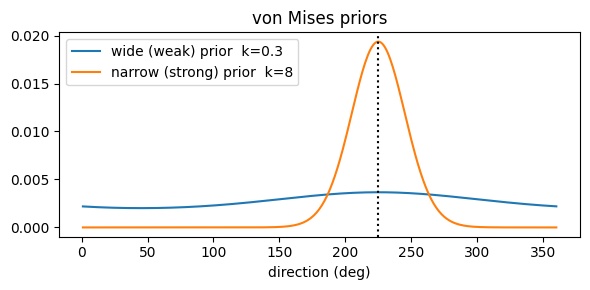

In [2]:
def vm_pdf(support_deg, mu_deg, k, norm=True):
    """von Mises pdf on a degree grid. Returns array (len(support) x n_mu)."""
    mu = np.atleast_1d(np.asarray(mu_deg, float))
    x  = np.deg2rad(np.asarray(support_deg, float))[:, None]
    u  = np.deg2rad(mu)[None, :]
    k  = float(k)
    if np.isinf(k) or k > 1e300:                     # delta-function limit
        out = np.zeros((len(support_deg), len(mu)))
        for j, mm in enumerate(mu):
            out[np.argmin(np.abs(np.asarray(support_deg) - mm)), j] = 1.0
    else:
        out = np.exp(k*np.cos(x-u) - k) / (2*np.pi*i0e(k))
    if norm:
        out = out / out.sum(0, keepdims=True)
    return out

# sanity: a prior at 225 with two widths
xs = DEG
plt.figure(figsize=(6,3))
for k,lbl in [(0.3,'wide (weak) prior'),(8,'narrow (strong) prior')]:
    plt.plot(xs, vm_pdf(xs,225,k), label=f'{lbl}  k={k}')
plt.axvline(225, ls=':', c='k'); plt.legend(); plt.xlabel('direction (deg)'); plt.title('von Mises priors'); plt.tight_layout()

## 2. Bayesian estimator lookup table — port of `SLGirshickBayesLookupTable.m`

This is the heart of the model. For one experimental condition (a likelihood strength `k_llh` and a prior `vonMises(mode, k_prior)`) it returns a matrix

`L[e, d] = P(report estimate e | true direction d)`

built in three steps:

1. **Measurement distribution** `P(m | d) = vonMises(d, k_llh)` — how the sensory measurement scatters around the true direction.
2. **Posterior for every possible measurement** `post(·|m) ∝ likelihood(·|m) · prior`. (Optionally times a cardinal prior, and/or made heavy-tailed by mixing with a uniform — the `weight_tail` parameter.)
3. **Readout** collapses each posterior to an estimate. **This one function is where MAP / BLS / Sampling differ** — swap the readout and you get a different observer. MAP can return *two* estimates when the posterior is bimodal (flat likelihood + off-prior direction); those are reported equiprobably, which is the mechanism behind the *switching* behaviour.

Finally it marginalises over measurements — `P(e|d) = Σ_m P(e|m)·P(m|d)` — to get the estimate distribution per true direction.

In [3]:
def girshick_lookup(motdir, k_llh, mode_prior, k_prior,
                    kcardinal=0.0, weight_tail=0.0,
                    readout="MAP", with_cardinal=False):
    """Return (DEG, L) where L[:, j] = P(estimate | motdir[j]) on the 1..360 grid."""
    m = DEG                                                   # possible measurements
    mPdfs = vm_pdf(m, motdir, k_llh)                          # P(m | displayed dir)  (360 x n_dir)
    like  = vm_pdf(DEG, m, k_llh)                             # P(dir | m)            (360 x 360)
    prior = np.tile(vm_pdf(DEG, mode_prior, k_prior), (1, len(m)))
    if weight_tail > 0:                                       # heavy-tailed prior
        prior = (1-weight_tail)*prior + weight_tail*(1/360)
    if with_cardinal and kcardinal > 0:
        card = 0.25*vm_pdf(DEG, [90,180,270,360], kcardinal).sum(1, keepdims=True)
        post = like * card * prior
    else:
        post = like * prior
    post = post / post.sum(0, keepdims=True)
    post = np.round(post*1e6)/1e6                             # de-noise so argmax finds true modes

    # ---- READOUT: the only part that changes between observers ----
    if readout == "MAP":
        percepts = [np.where(post[:,i]==post[:,i].max())[0] + 1 for i in range(len(m))]
    elif readout == "BLS":
        a = np.deg2rad(DEG)
        percepts = []
        for i in range(len(m)):
            p = post[:,i]
            mean = np.rad2deg(np.arctan2((p*np.sin(a)).sum(), (p*np.cos(a)).sum())) % 360
            percepts.append(np.array([int(round(mean)) or 360]))
    else:
        raise ValueError("readout must be 'MAP' or 'BLS' (Sampling has its own function)")

    # marginalise measurements: P(e|d) = sum_m P(e|m) P(m|d),  P(e|m)=1/n_ties
    L = np.zeros((360, len(motdir)))
    for i in range(len(m)):
        ps = percepts[i]; w = 1.0/len(ps)
        for p in ps:
            L[p-1, :] += w * mPdfs[i, :]
    return DEG, L / L.sum(0, keepdims=True)

## 3. Sampling readout — reconstructed (`SLBayesSamplingLookupTable.m` is **missing** from the repo)

The original repo *calls* `SLBayesSamplingLookupTable` for the sampling observer but the file is not included. The sampling observer reports a **draw** from the posterior instead of its peak/mean, so its estimate distribution *is* the posterior, marginalised over measurements:

`P(e | d) = Σ_m post(e | m) · P(m | d)`  →  a single clean matrix multiply.

If you later find Laquitaine's original file, compare against this; the marginal below is the standard definition.

In [4]:
def sampling_lookup(motdir, k_llh, mode_prior, k_prior, weight_tail=0.0):
    m = DEG
    mPdfs = vm_pdf(m, motdir, k_llh)                 # P(m|d)
    like  = vm_pdf(DEG, m, k_llh)
    prior = np.tile(vm_pdf(DEG, mode_prior, k_prior), (1, len(m)))
    if weight_tail > 0:
        prior = (1-weight_tail)*prior + weight_tail*(1/360)
    post = like * prior
    post = post / post.sum(0, keepdims=True)         # post[e | m]
    L = post @ mPdfs                                 # sum_m post(e|m) P(m|d)
    return DEG, L / L.sum(0, keepdims=True)

### Compare the three readouts on one condition
Weak likelihood, prior at 225°. Watch how MAP (switching) puts sharp mass at discrete estimates while BLS/Sampling are smoother — and how all three pull a true direction of 135° toward the 225° prior.

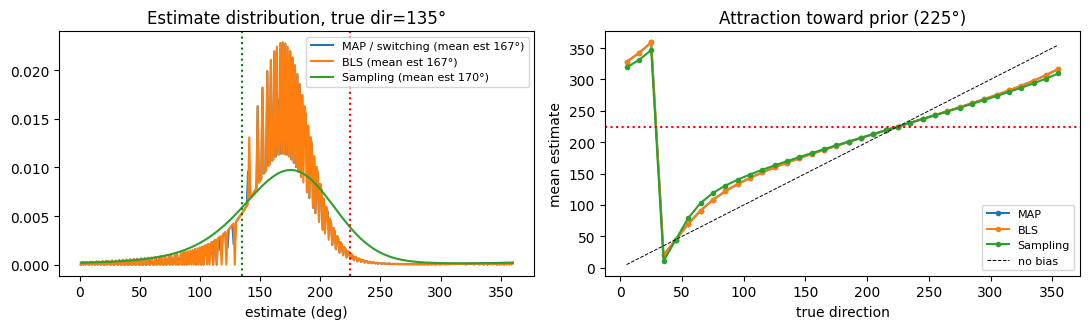

In [5]:
def circ_mean(p):
    a = np.deg2rad(DEG); return np.rad2deg(np.arctan2((p*np.sin(a)).sum(),(p*np.cos(a)).sum()))%360

md_dirs = np.arange(5,356,10)
kw = dict(k_llh=3.0, mode_prior=225, k_prior=2.0)
_,Lmap = girshick_lookup(md_dirs, readout="MAP", **kw)
_,Lbls = girshick_lookup(md_dirs, readout="BLS", **kw)
_,Lsmp = sampling_lookup(md_dirs, **kw)

j = list(md_dirs).index(135)
fig,ax = plt.subplots(1,2,figsize=(11,3.4))
for L,lbl in [(Lmap,'MAP / switching'),(Lbls,'BLS'),(Lsmp,'Sampling')]:
    ax[0].plot(DEG, L[:,j], label=f'{lbl} (mean est {circ_mean(L[:,j]):.0f}°)')
ax[0].axvline(135,ls=':',c='g'); ax[0].axvline(225,ls=':',c='r')
ax[0].set_title('Estimate distribution, true dir=135°'); ax[0].set_xlabel('estimate (deg)'); ax[0].legend(fontsize=8)
# bias curve: estimate mean vs true direction
for L,lbl in [(Lmap,'MAP'),(Lbls,'BLS'),(Lsmp,'Sampling')]:
    est=[circ_mean(L[:,k]) for k in range(len(md_dirs))]
    ax[1].plot(md_dirs, est, '-o', ms=3, label=lbl)
ax[1].plot(md_dirs, md_dirs,'k--',lw=.7,label='no bias')
ax[1].axhline(225,ls=':',c='r'); ax[1].set_title('Attraction toward prior (225°)')
ax[1].set_xlabel('true direction'); ax[1].set_ylabel('mean estimate'); ax[1].legend(fontsize=8)
plt.tight_layout()

## 4. Per-trial likelihood — port of the core of `SLgetLoglBayesianModel.m`

To *fit* the model you need `P(observed estimate | model, trial)`. The pipeline:

1. For each condition build `L[e|d]` with the chosen readout (§2/§3).
2. Assemble a per-trial matrix `P(e | trial)` by picking the column for each trial's true direction.
3. Mix in a lapse/random-guess rate: `P = (1−p_rand)·P_bayes + p_rand·(1/360)`.
4. **Convolve with motor noise** `vonMises(0, k_motor)` (circular convolution) → `P(estimate | model)`.
5. Read off the probability of the actually-reported estimate; `logL = Σ log P`.

`negLogL` is what an optimiser (`scipy.optimize.minimize`, Nelder–Mead — the same method as the MATLAB `fminsearch`) minimises.

In [6]:
def circ_convolve(P, kernel_col):
    """Circular convolution of each column of P (360 x T) with a 360-vector kernel."""
    Fp = np.fft.fft(P, axis=0)
    Fk = np.fft.fft(kernel_col)[:, None]
    return np.real(np.fft.ifft(Fp*Fk, axis=0))

def trial_loglike(estimates, dirs, cohs, pstds, params, readout="MAP"):
    """estimates,dirs,cohs,pstds: per-trial arrays. params: dict.
    Returns (neg_log_like, P_per_trial)."""
    k_llh_map = params['k_llh']       # {coh: k}
    k_pri_map = params['k_prior']     # {pstd: k}
    p_rand    = params['p_rand']
    k_motor   = params['k_motor']
    wt        = params.get('weight_tail', 0.0)
    mode      = params.get('mode_prior', 225)

    T = len(estimates)
    P = np.zeros((360, T))
    # loop over the (coh, pstd) conditions -> one lookup table each
    for coh in np.unique(cohs):
        for ps in np.unique(pstds):
            sel = (cohs==coh) & (pstds==ps)
            if not sel.any(): continue
            dd = np.unique(dirs[sel])
            if readout == "Sampling":
                _, L = sampling_lookup(dd, k_llh_map[coh], mode, k_pri_map[ps], weight_tail=wt)
            else:
                _, L = girshick_lookup(dd, k_llh_map[coh], mode, k_pri_map[ps],
                                       weight_tail=wt, readout=readout)
            col = {int(d): i for i, d in enumerate(dd)}
            idx = np.where(sel)[0]
            for t in idx:
                P[:, t] = L[:, col[int(dirs[t])]]
    # lapse + motor noise
    P = (1-p_rand)*P + p_rand*(1/360)
    motor = vm_pdf(DEG, 360, k_motor)[:, 0]         # kernel peaked at 0<->360
    P = circ_convolve(P, motor)
    P = np.clip(P, 1e-320, None)
    P = P / P.sum(0, keepdims=True)
    e_idx = (np.round(estimates).astype(int) % 360); e_idx[e_idx==0] = 360
    p_obs = P[e_idx-1, np.arange(T)]
    return -np.log(p_obs).sum(), p_obs

## 5. Load the real data (already exported to CSV — no MATLAB needed)

The repo ships `data/csv/data01_direction4priors.csv`: **12 subjects, 4 prior widths (std 10/20/40/80°), 3 coherences (.06/.12/.24), prior mean 225°, ~83k trials.** The reported estimate is stored as a 2-D vector `(estimate_x, estimate_y)`; convert to an angle with `atan2`.

In [8]:
import os, requests
 # @title Data retrieval

url = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
try:
  RequestAPI = requests.get(url)
except requests.ConnectionError:
  print("Failed to download data. Please contact steeve.laquitaine@epfl.ch")
else:
  if RequestAPI.status_code != requests.codes.ok:
    print("Failed to download data. Please contact steeve.laquitaine@epfl.ch")
  else:
    with open("data01_direction4priors.csv", "wb") as fid:
      fid.write(RequestAPI.content)
df = pd.read_csv("data01_direction4priors.csv")
df['estimate_deg'] = (np.degrees(np.arctan2(df.estimate_y, df.estimate_x)) % 360)
df.loc[df.estimate_deg==0,'estimate_deg'] = 360
df = df.dropna(subset=['estimate_deg','motion_direction'])
print(df)
print(df[['subject_id','motion_direction','motion_coherence','prior_std','estimate_deg']].head())
print('subjects', sorted(df.subject_id.unique()), '| priors', sorted(df.prior_std.unique()),
      '| cohs', sorted(df.motion_coherence.unique()))

       trial_index  trial_time  response_arrow_start_angle  motion_direction  \
0                1    0.000000                         NaN               225   
1                2    2.730730                         NaN               225   
2                3    4.913950                         NaN               235   
3                4    6.997296                         NaN               225   
4                5    9.097130                         NaN               215   
...            ...         ...                         ...               ...   
83208          198  571.895796                        47.0               205   
83209          199  574.708207                       238.0               265   
83210          200  577.408906                       300.0               245   
83211          201  579.720922                        10.0               185   
83212          202  582.602137                        33.0               185   

       motion_coherence  estimate_x  es

### Data signature: estimates are pulled toward 225° and pull is stronger when the prior is narrow / coherence low
This is the qualitative effect the model must reproduce.

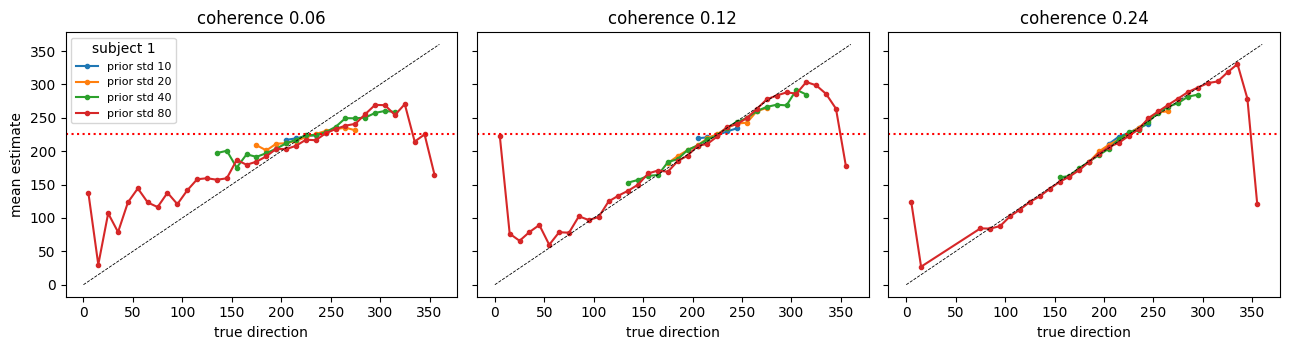

In [9]:
sub = df[df.subject_id==1]
fig,ax = plt.subplots(1,3,figsize=(13,3.6),sharey=True)
for a,coh in zip(ax, sorted(sub.motion_coherence.unique())):
    for ps in sorted(sub.prior_std.unique()):
        g = sub[(sub.motion_coherence==coh)&(sub.prior_std==ps)]
        m = g.groupby('motion_direction').estimate_deg.mean()
        a.plot(m.index, m.values, '-o', ms=3, label=f'prior std {ps}')
    a.plot([0,360],[0,360],'k--',lw=.6); a.axhline(225,ls=':',c='r')
    a.set_title(f'coherence {coh}'); a.set_xlabel('true direction')
ax[0].set_ylabel('mean estimate'); ax[0].legend(fontsize=8,title='subject 1')
plt.tight_layout()

## 6. Data vs. model prediction (one parameter set)

Not a fit — just plug in reasonable parameters and overlay the MAP/switching prediction on subject 1's data to confirm the pipeline is wired correctly. `k_llh` grows with coherence; `k_prior` grows as the prior narrows (std 10 ⇒ strong, std 80 ⇒ weak).

negLogL (subject 1, hand-set params, MAP): 39,334  over 8,562 trials


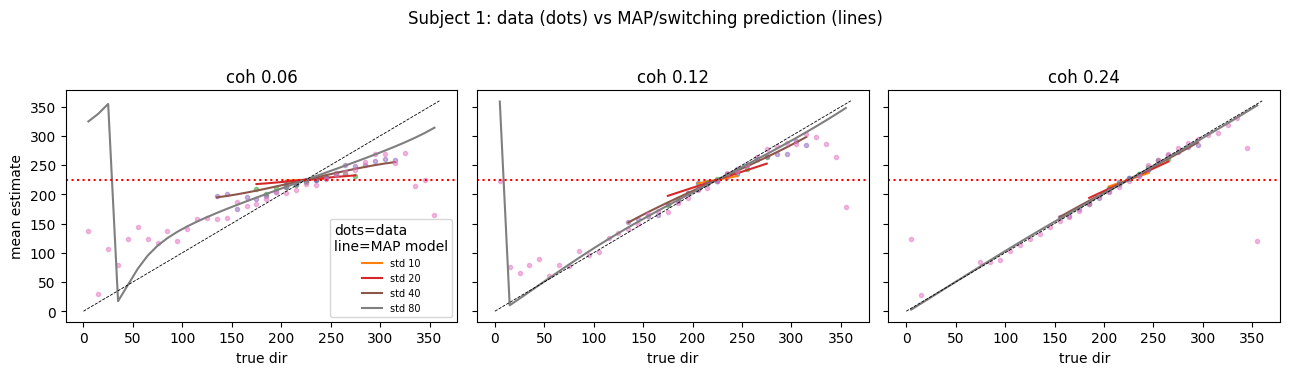

In [10]:
sub = df[df.subject_id==1].copy()
dirs = sub.motion_direction.values.astype(float)
cohs = sub.motion_coherence.values
pstds = sub.prior_std.values
est  = sub.estimate_deg.values

params = dict(
    k_llh   = {0.06:1.0, 0.12:3.0, 0.24:8.0},     # reliability rises with coherence
    k_prior = {80:0.5,   40:1.0,   20:2.5, 10:6.0},# prior sharpens as std shrinks
    p_rand  = 0.02, k_motor = 30.0, mode_prior = 225)

# model mean estimate per (coh, pstd, dir)
def model_mean_curve(coh, ps, readout="MAP"):
    dd = np.unique(dirs[(cohs==coh)&(pstds==ps)])
    _,L = girshick_lookup(dd, params['k_llh'][coh], 225, params['k_prior'][ps], readout=readout)
    return dd, np.array([circ_mean(L[:,i]) for i in range(len(dd))])

fig,ax = plt.subplots(1,3,figsize=(13,3.6),sharey=True)
for a,coh in zip(ax, sorted(np.unique(cohs))):
    for ps in sorted(np.unique(pstds)):
        g = sub[(sub.motion_coherence==coh)&(sub.prior_std==ps)]
        m = g.groupby('motion_direction').estimate_deg.mean()
        a.plot(m.index, m.values, 'o', ms=3, alpha=.5)
        dd,mc = model_mean_curve(coh, ps)
        a.plot(dd, mc, '-', lw=1.5, label=f'std {ps}')
    a.plot([0,360],[0,360],'k--',lw=.6); a.axhline(225,ls=':',c='r')
    a.set_title(f'coh {coh}'); a.set_xlabel('true dir')
ax[0].set_ylabel('mean estimate'); ax[0].legend(fontsize=7,title='dots=data\nline=MAP model')
plt.suptitle('Subject 1: data (dots) vs MAP/switching prediction (lines)', y=1.03)
plt.tight_layout()

nll,_ = trial_loglike(est, dirs, cohs, pstds, params, readout="MAP")
print(f'negLogL (subject 1, hand-set params, MAP): {nll:,.0f}  over {len(est):,} trials')

## 7. Fitting hook (optional, slow)

Wrap `trial_loglike` in an objective and hand it to `scipy.optimize.minimize(method="Nelder-Mead")` — the direct analogue of the MATLAB `fminsearch`/`MLft5` routine. Sketch below (commented so the notebook runs fast); flatten the parameter dict to a vector, and remember to fit **many random restarts** as the original does, because the MAP likelihood surface is multimodal.

In [ ]:
# from scipy.optimize import minimize
# cohs_u=[0.06,0.12,0.24]; ps_u=[80,40,20,10]
# def unpack(x):
#     return dict(k_llh=dict(zip(cohs_u,x[:3])), k_prior=dict(zip(ps_u,x[3:7])),
#                 p_rand=x[7], k_motor=x[8], mode_prior=225)
# def obj(x):
#     if (x<0).any() or x[7]>1: return 1e9
#     return trial_loglike(est,dirs,cohs,pstds,unpack(x),readout="MAP")[0]
# x0=np.array([1,3,8, .5,1,2.5,6, .02, 30.])
# res=minimize(obj,x0,method="Nelder-Mead",options=dict(maxiter=2000,xatol=1e-2,fatol=1e-1))
# print(res.x, res.fun)
print("Fitting cell is commented out — uncomment to run (minutes per restart).")

Fitting cell is commented out — uncomment to run (minutes per restart).


## 8. Extension scaffold — the **online / sequential** observer

The current model uses a **fixed** prior per block (`k_prior` chosen by `prior_std`). An **online** observer instead **updates its prior trial-by-trial** from the directions it has seen. Because the true generative prior here is a von Mises at 225°, a natural online rule keeps a running estimate of the prior's **circular mean** and **concentration** and feeds them into the same `girshick_lookup`.

Below is a minimal, runnable skeleton: a delta-rule update of the prior's circular sufficient statistics (resultant vector), converted to a von Mises `(mode, k)` each trial. Swap in whatever learning rule your hypothesis needs (Bayesian filtering over prior parameters, leaky integrator, change-point/`switching` prior, etc.).

To make it a full online *observer*: at trial t, call girshick_lookup(..., mode_prior=modes[t], k_prior=ks[t])
then read P(estimate|dir) for that single trial. Fit the learning-rate lr by max-likelihood like any other param.


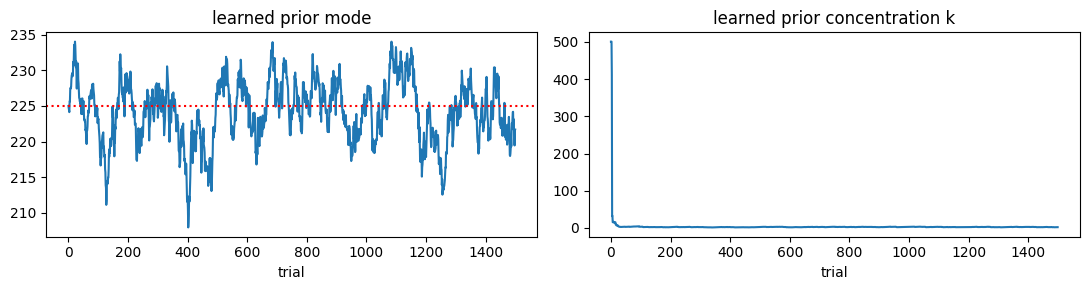

In [ ]:
def online_prior_stats(seen_dirs, lr=0.05, init_mode=225, init_k=1.0):
    """Delta-rule running circular mean + concentration from directions seen so far.
    Returns lists of (mode_deg, k) evolving over trials."""
    # running resultant vector R = mean of unit vectors, decayed by lr
    cx, cy = np.cos(np.deg2rad(init_mode)), np.sin(np.deg2rad(init_mode))
    Rlen = init_k/(init_k+1)                      # rough init
    modes, ks = [], []
    for d in seen_dirs:
        ux, uy = np.cos(np.deg2rad(d)), np.sin(np.deg2rad(d))
        cx = (1-lr)*cx + lr*ux
        cy = (1-lr)*cy + lr*uy
        mode = np.rad2deg(np.arctan2(cy, cx)) % 360
        R = min(np.hypot(cx, cy), 0.999)
        # Fisher approx: k from mean resultant length R
        k = R*(2-R**2)/(1-R**2)
        modes.append(mode); ks.append(k)
    return np.array(modes), np.array(ks)

# demo: feed subject 1's trial order through the learner
seen = df[df.subject_id==1].sort_values('trial_index').motion_direction.values.astype(float)
modes, ks = online_prior_stats(seen[:1500], lr=0.03)
fig,ax=plt.subplots(1,2,figsize=(11,3))
ax[0].plot(modes); ax[0].axhline(225,ls=':',c='r'); ax[0].set_title('learned prior mode'); ax[0].set_xlabel('trial')
ax[1].plot(ks); ax[1].set_title('learned prior concentration k'); ax[1].set_xlabel('trial')
plt.tight_layout()
print("To make it a full online *observer*: at trial t, call girshick_lookup(..., mode_prior=modes[t], k_prior=ks[t])")
print("then read P(estimate|dir) for that single trial. Fit the learning-rate lr by max-likelihood like any other param.")

## 9. Where to go next

- **Switching observer** = the MAP readout above. To study switching explicitly, inspect trials where `girshick_lookup` returns **two** MAP percepts (bimodal posterior) — those are the discrete "switch" events the paper is about.
- **Sampling** = §3; already runnable. If you locate the original `SLBayesSamplingLookupTable.m`, diff it against this marginal.
- **Online/sequential** = §8; replace the delta rule with your learning model and fit `lr`.
- **Fitting** = §7; use many restarts (the MATLAB code uses ~10 initial-parameter sets) because the MAP likelihood is multimodal.
- **Speed**: the lookup tables only depend on `(k_llh, k_prior)` — cache them per condition (done implicitly in §4) rather than per trial.

See the companion document *Model_explainer.md* for the full MATLAB→Python mapping and porting notes.

## 10. Reproducing Figure 6C (Laquitaine & Gardner) — MATLAB-style distribution overlay

Built on the functions already defined above (`vm_pdf`, `girshick_lookup`, `sampling_lookup`, `circ_convolve`, `DEG`, `df`). Like the MATLAB code it **builds** per-condition estimate-distribution matrices on a fixed 10° grid (`makeDataDist` / `SLmakePredictionsBayesianModel` + `SLcumSumInBin`) and draws them centered on the prior mean (`SLdrawModelsPredictionHistwithDataCentered`):

- x-axis = signed distance to the prior mean, **0 = prior**
- **data** = filled area, **model** = smooth line
- gray marker = motion direction (moves), blue bar = prior mode (fixed at 0)

In [11]:
# grid + Switching observer + full model distribution (adds lapse & motor noise)
BINS = np.arange(0, 361, 10)            # 36 x 10-deg bins (makeDataDist: 0:10:360)
BINC = (BINS[:-1] + BINS[1:]) / 2       # bin centers 5,15,...,355

def switching_lookup(motdir, k_llh, k_prior, mode_prior=225):
    # Switching observer (Eq. 6-7): delta at prior mean + sensory distribution;
    # p_prior = k_prior/(k_prior+k_llh)
    motdir = np.atleast_1d(motdir).astype(float)
    p_prior = k_prior / (k_prior + k_llh)
    prior = np.zeros(360); prior[int(round(mode_prior)) - 1] = 1.0
    L = np.zeros((360, len(motdir)))
    for j, d in enumerate(motdir):
        L[:, j] = p_prior * prior + (1 - p_prior) * vm_pdf(DEG, d, k_llh)[:, 0]
    return L / L.sum(0, keepdims=True)

def estimate_dist_1deg(motdir, k_llh, k_prior, params, readout='Switching'):
    # P(estimate|dir) at 1-deg resolution, with lapse + motor noise
    if   readout == 'Switching': L = switching_lookup(motdir, k_llh, k_prior, params.get('mode_prior', 225))
    elif readout == 'Sampling':  _, L = sampling_lookup(motdir, k_llh, params.get('mode_prior', 225), k_prior)
    else:                        _, L = girshick_lookup(motdir, k_llh, params.get('mode_prior', 225), k_prior, readout=readout)
    L = (1 - params['p_rand']) * L + params['p_rand'] / 360
    L = circ_convolve(L, vm_pdf(DEG, 360, params['k_motor'])[:, 0])
    return L / L.sum(0, keepdims=True)

def rebin_10deg(p1):
    # SLcumSumInBin: sum a length-360 pmf into 36 bins, bin j = (10(j-1), 10j]
    idx = np.ceil(DEG / 10).astype(int) - 1
    out = np.zeros(36); np.add.at(out, idx, p1); return out

In [17]:
# build the 36 x Ncond data and model matrices (makeDataDist / SLmakePredictionsBayesianModel)
def build_conditions(dat, cohs=None, pstds=None, dirs=None):
    d = dat
    if cohs  is not None: d = d[d.motion_coherence.isin(np.atleast_1d(cohs))]
    if pstds is not None: d = d[d.prior_std.isin(np.atleast_1d(pstds))]
    if dirs  is not None: d = d[d.motion_direction.isin(np.atleast_1d(dirs))]
    cond = d[['prior_std','motion_coherence','motion_direction']].drop_duplicates().values
    return cond[np.lexsort((cond[:,2], cond[:,1], cond[:,0]))]

def circular_kde(est, kappa=25):
    # von Mises kernel density = Python equivalent of MATLAB makePdf('smooth') / ksdensity, on 1..360
    if len(est) == 0: return np.full(360, np.nan)
    d = np.zeros(360)
    for e in est: d += vm_pdf(DEG, float(e), kappa)[:, 0]
    return d / d.sum()

def make_data_dist(dat, cond, smooth=False, kappa=12, fold=False):
    # smooth=False -> raw 36 x 10-deg histogram; smooth=True -> 360-pt von Mises KDE (makePdf 'smooth')
    # fold=True    -> pool the symmetric mirror direction about the prior (225) to double sparse counts
    nrow = 360 if smooth else 36
    P = np.full((nrow, len(cond)), np.nan); n = np.zeros(len(cond), int)
    for i, (ps, coh, d) in enumerate(cond):
        sub = dat[(dat.prior_std==ps) & (dat.motion_coherence==coh)]
        e = sub[sub.motion_direction==d].estimate_deg.values
        if fold and int(d) != 225:
            md = (450 - d) % 360
            e = np.concatenate([e, (450 - sub[sub.motion_direction==md].estimate_deg.values) % 360])
        n[i] = len(e)
        if len(e):
            if smooth:
                P[:, i] = circular_kde(e, kappa)
            else:
                cnt, _ = np.histogram(e, bins=BINS); P[:, i] = cnt/cnt.sum() if cnt.sum() else np.nan
    return P, n

def make_predictions(cond, params, readout='Switching'):
    P = np.zeros((36, len(cond)))
    for i, (ps, coh, d) in enumerate(cond):
        p1 = estimate_dist_1deg([float(d)], params['k_llh'][coh], params['k_prior'][ps], params, readout)[:, 0]
        P[:, i] = rebin_10deg(p1); P[:, i] /= P[:, i].sum()
    return P

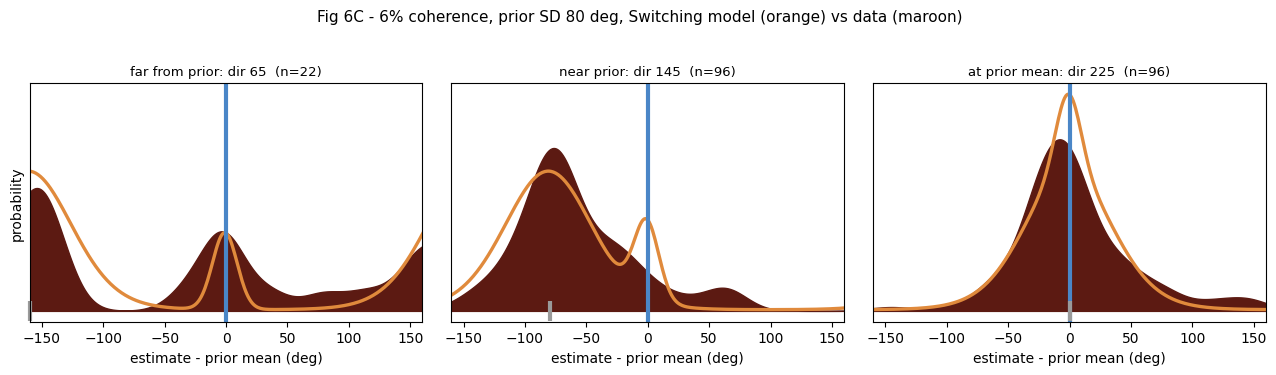

In [18]:
# centered drawing (SLvectors2signedAngle + SLdrawModelsPredictionHistwithDataCentered)
def signed_angle(v, ref=225):
    return ((np.asarray(v, float) - ref + 180) % 360) - 180

def _grid_for(nrow):
    return DEG if nrow == 360 else BINC     # smooth density -> 1-deg grid, raw hist -> 36 bin centers

def draw_hist_centered(Pdata, Ppred, cond, n=None, mode_prior=225, titles=None, suptitle=None, xlim=(-160,160)):
    fig, axes = plt.subplots(1, len(cond), figsize=(4.3*len(cond), 3.6), sharey=True, squeeze=False); axes = axes[0]
    for i, ax in enumerate(axes):
        if Pdata is not None and not np.all(np.isnan(Pdata[:, i])):
            xd = signed_angle(_grid_for(Pdata.shape[0]), mode_prior); od = np.argsort(xd)
            ax.fill_between(xd[od], Pdata[od, i], color='#5c1a12',
                            step=None if Pdata.shape[0]==360 else 'mid')      # data (area)
        if Ppred is not None:
            xp = signed_angle(_grid_for(Ppred.shape[0]), mode_prior); op = np.argsort(xp)
            ax.plot(xp[op], Ppred[op, i], color='#e08a3c', lw=2.4)            # model (line)
        ax.axvline(0, color='#4a86c7', lw=3)                                  # prior mode (0)
        ax.plot([signed_angle(cond[i,2], mode_prior)], [0], marker='|', ms=14, mec='#9a9a9a', mew=3, clip_on=False)
        ax.set_xlim(*xlim); ax.set_yticks([]); ax.set_xlabel('estimate - prior mean (deg)')
        t = titles[i] if titles else f'dir {int(cond[i,2])}'
        if n is not None: t += f'  (n={n[i]})'
        ax.set_title(t, fontsize=9.5)
    axes[0].set_ylabel('probability')
    if suptitle: fig.suptitle(suptitle, y=1.03, fontsize=11)
    plt.tight_layout(); return fig

def fig6c(dat, params, coh=0.06, pstd=80, dirs=(65, 145, 225), readout='Switching',
          smooth=True, kappa=12, fold=True):
    # paper's Fig 6C directions: far 160 deg (65), near 80 deg (145), at prior (225)
    cond = np.array([[pstd, coh, d] for d in dirs], float)
    Pdata, n = make_data_dist(dat, cond, smooth=smooth, kappa=kappa, fold=fold)
    if smooth:   # match data resolution (1-deg) so data & model share the same y-scale
        Ppred = np.column_stack([estimate_dist_1deg([float(d)], params['k_llh'][coh], params['k_prior'][ps], params, readout)[:, 0]
                                 for (ps, coh, d) in cond])
    else:
        Ppred = make_predictions(cond, params, readout)
    labels = ['far from prior', 'near prior', 'at prior mean'][:len(dirs)]
    titles = [f'{lab}: dir {int(d)}' for lab, d in zip(labels, dirs)]
    sup = f'Fig 6C - {int(coh*100)}% coherence, prior SD {pstd} deg, {readout} model (orange) vs data (maroon)'
    return draw_hist_centered(Pdata, Ppred, cond, n, params.get('mode_prior', 225), titles, sup)


### (optional) Fit subject 1 by maximum likelihood

Defines the objective and the optimizer. Guarded by `RUN_FIT`: with `RUN_FIT = False` the notebook just uses the hand-set `params6c` (fast). Set `RUN_FIT = True` to actually fit subject 1 — a few minutes, since the likelihood is multimodal and uses several restarts — after which `params6c` holds the fitted values and every Fig 6C below uses them. Fit parameters: 3 `k_llh` (per coherence), 4 `k_prior` (per prior width), `p_rand`, `k_motor`.

The search uses the paper's **10 initial‑parameter sets** (`paper_init_grid` — a 3×3 grid of {true, 8× stronger, 8× weaker} for likelihood × prior, plus an all‑equal set), mirroring the MATLAB `k0`, and keeps the best fit — because the likelihood is multimodal.

In [15]:
# (optional) fit subject 1; Fig 6C below then uses the fitted params6c
from scipy.optimize import minimize

def paper_init_grid(kllh0=(1., 3., 8.), kprior0=(0.7, 2.8, 8.7, 33.3), prand0=0.02, kmotor0=30.):
    # 10 initial-parameter sets like MLft5 k0: 3x3 {true, 8x stronger, 8x weaker} of llh x prior + all-equal
    kllh0 = np.array(kllh0, float); kprior0 = np.array(kprior0, float); g = []
    for lf in (1, 8, 1/8):
        for pf in (1, 8, 1/8):
            g.append(list(kllh0*lf) + list(kprior0*pf) + [prand0, kmotor0])
    m = float(np.mean(np.r_[kllh0, kprior0]))
    g.append([m]*3 + [m]*4 + [prand0, kmotor0])   # set 10: all llh & prior equal
    return g

sub1 = df[df.subject_id == 1]                        # one subject (do NOT pool across subjects)

# hand-set defaults (used unless you fit); k_prior = paper's true prior concentrations
params6c = dict(k_llh   = {0.06:1.0, 0.12:3.0, 0.24:8.0},
                k_prior = {80:0.7, 40:2.8, 20:8.7, 10:33.3},
                p_rand=0.03, k_motor=30.0, mode_prior=225)

RUN_FIT     = True          # <-- set True to fit (a few minutes)
FIT_READOUT = 'Switching'    # 'Switching' | 'MAP' | 'BLS' | 'Sampling'

def _trial_negll(est, dirs, cohs, pstds, params, readout):
    # negative log-likelihood of the estimates (works for any readout; uses estimate_dist_1deg)
    P = np.zeros((360, len(est)))
    for coh in np.unique(cohs):
        for ps in np.unique(pstds):
            sel = (cohs == coh) & (pstds == ps)
            if not sel.any(): continue
            dd = np.unique(dirs[sel])
            L = estimate_dist_1deg(dd, params['k_llh'][coh], params['k_prior'][ps], params, readout)
            col = {int(d): k for k, d in enumerate(dd)}
            for t in np.where(sel)[0]:
                P[:, t] = L[:, col[int(dirs[t])]]
    idx = (np.round(est).astype(int) % 360); idx[idx == 0] = 360
    p_obs = np.clip(P[idx - 1, np.arange(len(est))], 1e-320, None)
    return -np.log(p_obs).sum()

if RUN_FIT:
    est   = sub1.estimate_deg.values.astype(float)
    dirs  = sub1.motion_direction.values.astype(float)
    cohs  = sub1.motion_coherence.values
    pstds = sub1.prior_std.values
    cohs_u = sorted(np.unique(cohs))                 # [0.06, 0.12, 0.24]
    ps_u   = sorted(np.unique(pstds), reverse=True)  # [80, 40, 20, 10]
    def unpack(x):
        return dict(k_llh=dict(zip(cohs_u, x[0:3])), k_prior=dict(zip(ps_u, x[3:7])),
                    p_rand=x[7], k_motor=x[8], mode_prior=225)
    def negll(x):
        if np.any(x < 0) or x[7] > 1: return 1e9
        return _trial_negll(est, dirs, cohs, pstds, unpack(x), FIT_READOUT)
    starts = paper_init_grid()   # 10-set grid (paper / MLft5 k0)
    best = min((minimize(negll, np.array(s, float), method='Nelder-Mead',
                         options=dict(maxiter=3000, xatol=1e-2, fatol=1e-1)) for s in starts),
               key=lambda r: r.fun)
    params6c = unpack(best.x)
    K = len(best.x); AIC = 2*K + 2*best.fun; BIC = K*np.log(len(est)) + 2*best.fun
    print(f'fitted subject 1 ({FIT_READOUT}):  negLL={best.fun:.1f}  AIC={AIC:.1f}  BIC={BIC:.1f}')
    for k, v in params6c.items(): print('  ', k, '=', v)
else:
    print('RUN_FIT is False -> using hand-set params6c. Set RUN_FIT=True to fit (a few minutes).')

fitted subject 1 (Switching):  negLL=38488.5  AIC=76995.0  BIC=77058.5
   k_llh = {np.float64(0.06): np.float64(2.960232397422183), np.float64(0.12): np.float64(14.283370610733456), np.float64(0.24): np.float64(157.47556887196075)}
   k_prior = {np.int64(80): np.float64(0.44882394629700295), np.int64(40): np.float64(1.6532027739742219), np.int64(20): np.float64(4.644934339737586), np.int64(10): np.float64(39.46991066432787)}
   p_rand = 0.020332133357988204
   k_motor = 32.70498592049925
   mode_prior = 225


### Run Fig 6C for subject 1

Uses `params6c` from the fit cell above (hand-set unless you set `RUN_FIT = True`). `readout` can be `"Switching"`, `"MAP"`, `"BLS"`, `"Sampling"`.

In [1]:
fig6c(sub1, params6c, coh=0.06, pstd=80, dirs=(65, 145, 225),
      readout='Switching', smooth=False, kappa=12, fold=False)
plt.show()

NameError: name 'fig6c' is not defined

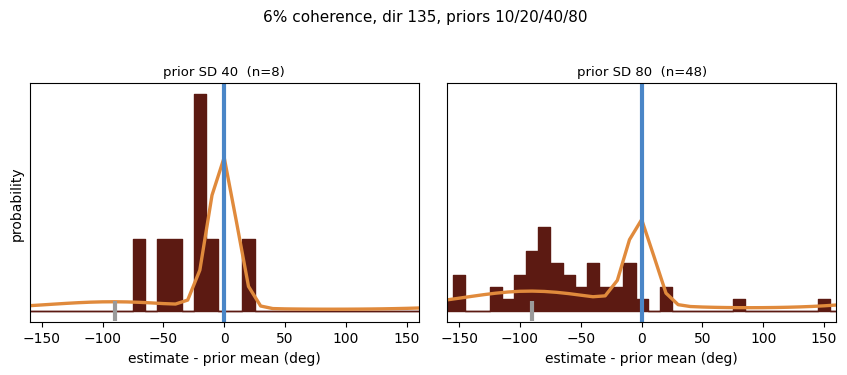

In [ ]:
# any set of conditions the same way: all four priors at one direction, 6% coherence
cond = build_conditions(sub1, cohs=0.06, dirs=135)
Pd, n = make_data_dist(sub1, cond); Pp = make_predictions(cond, params6c, 'Switching')
draw_hist_centered(Pd, Pp, cond, n, titles=[f'prior SD {int(p)}' for p in cond[:,0]],
                   suptitle='6% coherence, dir 135, priors 10/20/40/80')
plt.show()

## 11. Fit all subjects & compare models (optional, slow)

Reusable `fit_subject(sub, readout)` (max-likelihood, several restarts), then two guarded batch jobs:

- `RUN_FIT_ALL` — fit every subject with one readout, storing fitted params + AIC/BIC.
- `RUN_MODEL_COMPARISON` — fit `Switching / MAP / BLS / Sampling` per subject and tabulate AIC, the number of subjects each model wins, and the mean AIC difference vs Switching (the paper's Fig 6A/B).

Both default to `False` so the notebook runs instantly. Each full run is minutes per subject (model comparison ≈ an hour for all 12 × 4).

In [ ]:
# reusable single-subject fit (uses _trial_negll and minimize defined in Section 10)
def fit_subject(sub, readout='Switching', starts=None, maxiter=3000):
    est   = sub.estimate_deg.values.astype(float)
    dirs  = sub.motion_direction.values.astype(float)
    cohs  = sub.motion_coherence.values
    pstds = sub.prior_std.values
    cohs_u = sorted(np.unique(cohs)); ps_u = sorted(np.unique(pstds), reverse=True)
    def unpack(x):
        return dict(k_llh=dict(zip(cohs_u, x[0:3])), k_prior=dict(zip(ps_u, x[3:7])),
                    p_rand=x[7], k_motor=x[8], mode_prior=225)
    def negll(x):
        if np.any(x < 0) or x[7] > 1: return 1e9
        return _trial_negll(est, dirs, cohs, pstds, unpack(x), readout)
    if starts is None:
        starts = paper_init_grid()   # 10-set grid (paper / MLft5 k0)
    best = min((minimize(negll, np.array(s, float), method='Nelder-Mead',
                         options=dict(maxiter=maxiter, xatol=1e-2, fatol=1e-1)) for s in starts),
               key=lambda r: r.fun)
    return unpack(best.x), best.fun, len(est)

In [ ]:
# --- fit ALL subjects with one readout ---
RUN_FIT_ALL     = False          # <-- set True (minutes per subject)
FIT_ALL_READOUT = 'Switching'
if RUN_FIT_ALL:
    fits = {}
    for s in sorted(df.subject_id.unique()):
        p, nll, N = fit_subject(df[df.subject_id == s], readout=FIT_ALL_READOUT)
        K = 9
        fits[int(s)] = dict(params=p, negLL=nll, AIC=2*K + 2*nll, BIC=K*np.log(N) + 2*nll, n=N)
        print(f'subj {int(s):>2}:  negLL={nll:8.1f}   AIC={fits[int(s)]["AIC"]:8.1f}   n={N}')
    fitted_params_all = {s: fits[s]['params'] for s in fits}   # subject -> params dict
else:
    print('RUN_FIT_ALL is False -> set True to fit all 12 subjects (', FIT_ALL_READOUT, ').')

RUN_FIT_ALL is False -> set True to fit all 12 subjects ( Switching ).


In [ ]:
# --- model comparison: fit each readout x subject, tabulate AIC (paper Fig 6A/B) ---
RUN_MODEL_COMPARISON = False     # <-- set True (slow: ~1 hr for 12 subjects x 4 models)
COMPARE_READOUTS = ['Switching', 'MAP', 'BLS', 'Sampling']
if RUN_MODEL_COMPARISON:
    rows = []
    for s in sorted(df.subject_id.unique()):
        sub = df[df.subject_id == s]; row = {'subject': int(s)}
        for r in COMPARE_READOUTS:
            _, nll, N = fit_subject(sub, readout=r)
            row['AIC_' + r] = 2*9 + 2*nll
        rows.append(row); print('done subject', int(s))
    aic = pd.DataFrame(rows).set_index('subject')
    aiccols = [c for c in aic.columns if c.startswith('AIC_')]
    aic['best'] = aic[aiccols].idxmin(axis=1).str.replace('AIC_', '')
    print(aic.round(0)); print()
    print('subjects best-fit by each model:'); print(aic['best'].value_counts())
    dAIC = aic[aiccols].sub(aic['AIC_Switching'], axis=0)
    print('\nmean (AIC_model - AIC_Switching) over subjects  (>0 favors Switching):')
    print(dAIC.mean().round(1))
else:
    print('RUN_MODEL_COMPARISON is False -> set True to fit', COMPARE_READOUTS, 'x subjects.')

RUN_MODEL_COMPARISON is False -> set True to fit ['Switching', 'MAP', 'BLS', 'Sampling'] x subjects.
